PERFORMANCE METRICS FOR THE 3 MODELS BEFORE TUNING

In [48]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    log_loss
)

print("TensorFlow version:", tf.__version__)


@tf.keras.utils.register_keras_serializable(
    package="FallDetection"
)
class ResNet50Preprocessing(tf.keras.layers.Layer):

    def call(self, inputs):
        return tf.keras.applications.resnet50.preprocess_input(
            inputs
        )

    def get_config(self):
        return super().get_config()


TensorFlow version: 2.21.0


In [2]:
PROJECT_ROOT = Path("..")

VALIDATION_DIRECTORY = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "val"
)

MODELS_DIRECTORY = PROJECT_ROOT / "models"

OUTPUT_DIRECTORY = (
    PROJECT_ROOT
    / "outputs"
    / "model_comparison"
)

OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_PATHS = {
    "Custom CNN": (
        MODELS_DIRECTORY
        / "best_custom_cnn.keras"
    ),

    "MobileNetV3": (
        MODELS_DIRECTORY
        / "best_mobilenetv3.keras"
    ),

    "ResNet50": (
        MODELS_DIRECTORY
        / "final_resnet50.keras"
    )
}

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
THRESHOLD = 0.50

In [3]:
print("Validation directory:")
print(VALIDATION_DIRECTORY.resolve())

if not VALIDATION_DIRECTORY.exists():
    raise FileNotFoundError(
        f"Validation directory not found: "
        f"{VALIDATION_DIRECTORY.resolve()}"
    )

print("\nSaved models:")

for model_name, model_path in MODEL_PATHS.items():

    if model_path.exists():
        print(
            f"{model_name}: FOUND"
            f"\nPath: {model_path.resolve()}\n"
        )

    else:
        print(
            f"{model_name}: NOT FOUND"
            f"\nExpected path: {model_path.resolve()}\n"
        )

Validation directory:
C:\Users\GArvit\Desktop\Fall Detection\data\processed\val

Saved models:
Custom CNN: FOUND
Path: C:\Users\GArvit\Desktop\Fall Detection\models\best_custom_cnn.keras

MobileNetV3: FOUND
Path: C:\Users\GArvit\Desktop\Fall Detection\models\best_mobilenetv3.keras

ResNet50: FOUND
Path: C:\Users\GArvit\Desktop\Fall Detection\models\final_resnet50.keras



In [4]:
class_folders = sorted([
    folder.name
    for folder in VALIDATION_DIRECTORY.iterdir()
    if folder.is_dir()
])

print("Validation class folders:")
print(class_folders)

Validation class folders:
['fall', 'no_fall']


In [5]:
CLASS_NAMES = [
    "no_fall",
    "fall"
]

print("Class mapping:")

for class_index, class_name in enumerate(CLASS_NAMES):
    print(
        f"{class_index} = {class_name}"
    )

Class mapping:
0 = no_fall
1 = fall


In [6]:
validation_dataset = (
    tf.keras.utils.image_dataset_from_directory(
        VALIDATION_DIRECTORY,
        class_names=CLASS_NAMES,
        label_mode="binary",
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )
)

print("\nTensorFlow class names:")
print(validation_dataset.class_names)

Found 361 files belonging to 2 classes.

TensorFlow class names:
['no_fall', 'fall']


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

validation_dataset = validation_dataset.prefetch(
    buffer_size=AUTOTUNE
)

In [49]:
true_labels = np.concatenate([
    batch_labels.numpy().reshape(-1)
    for batch_images, batch_labels
    in validation_dataset
]).astype(int)

validation_labels = true_labels.copy()

print("Number of validation labels:")
print(len(true_labels))

print("\nClass distribution:")

unique_classes, class_counts = np.unique(
    true_labels,
    return_counts=True
)

for class_index, class_count in zip(
    unique_classes,
    class_counts
):
    print(
        f"{CLASS_NAMES[class_index]}: "
        f"{class_count}"
    )


Number of validation labels:
361

Class distribution:
no_fall: 215
fall: 146


In [ ]:
def evaluate_binary_model(
    model_name,
    model_path,
    dataset,
    true_labels,
    threshold=0.50
):
    """
    Load and evaluate one binary image-classification model.

    Assumptions:
    1. The model has one sigmoid output.
    2. Output probability represents the Fall class.
    3. No Fall is label 0.
    4. Fall is label 1.
    """

    print("\n" + "=" * 70)
    print(f"Evaluating: {model_name}")
    print("=" * 70)

    if not model_path.exists():
        raise FileNotFoundError(
            f"Model file not found: "
            f"{model_path.resolve()}"
        )

    model = tf.keras.models.load_model(
        model_path,
        compile=False,
        custom_objects={
            "ResNet50Preprocessing": ResNet50Preprocessing
        }
    )

    print("Model loaded successfully.")

    for batch_images, _ in dataset.take(1):
        _ = model.predict(
            batch_images,
            verbose=0
        )

    start_time = time.perf_counter()

    raw_predictions = model.predict(
        dataset,
        verbose=1
    )

    end_time = time.perf_counter()

    total_prediction_time = (
        end_time - start_time
    )

    probabilities = np.asarray(
        raw_predictions
    ).reshape(-1)

    if len(probabilities) != len(true_labels):
        raise ValueError(
            f"{model_name} produced "
            f"{len(probabilities)} predictions, "
            f"but there are "
            f"{len(true_labels)} true labels."
        )

    probabilities = np.clip(
        probabilities,
        1e-7,
        1 - 1e-7
    )

    predicted_labels = (
        probabilities >= threshold
    ).astype(int)

    confusion = confusion_matrix(
        true_labels,
        predicted_labels,
        labels=[0, 1]
    )

    true_negative = confusion[0, 0]
    false_positive = confusion[0, 1]
    false_negative = confusion[1, 0]
    true_positive = confusion[1, 1]

    accuracy = accuracy_score(
        true_labels,
        predicted_labels
    )

    precision = precision_score(
        true_labels,
        predicted_labels,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        true_labels,
        predicted_labels,
        pos_label=1,
        zero_division=0
    )

    f1 = f1_score(
        true_labels,
        predicted_labels,
        pos_label=1,
        zero_division=0
    )

    if true_negative + false_positive > 0:
        specificity = (
            true_negative
            / (true_negative + false_positive)
        )
    else:
        specificity = np.nan

    if true_negative + false_negative > 0:
        negative_predictive_value = (
            true_negative
            / (true_negative + false_negative)
        )
    else:
        negative_predictive_value = np.nan

    balanced_accuracy = (
        recall + specificity
    ) / 2

    roc_auc = roc_auc_score(
        true_labels,
        probabilities
    )

    precision_recall_auc = (
        average_precision_score(
            true_labels,
            probabilities
        )
    )

    binary_crossentropy = log_loss(
        true_labels,
        probabilities,
        labels=[0, 1]
    )

    average_time_per_image = (
        total_prediction_time
        / len(true_labels)
    )

    images_per_second = (
        len(true_labels)
        / total_prediction_time
    )

    model_size_megabytes = (
        model_path.stat().st_size
        / (1024 ** 2)
    )

    report = classification_report(
        true_labels,
        predicted_labels,
        target_names=[
            "No Fall",
            "Fall"
        ],
        digits=4,
        zero_division=0
    )

    print("\nConfusion matrix:")
    print(confusion)

    print("\nConfusion-matrix values:")
    print(
        f"True Negative:  {true_negative}"
    )
    print(
        f"False Positive: {false_positive}"
    )
    print(
        f"False Negative: {false_negative}"
    )
    print(
        f"True Positive:  {true_positive}"
    )

    print("\nStandard metrics:")
    print(
        f"Accuracy: {accuracy:.4f}"
    )
    print(
        f"Precision: {precision:.4f}"
    )
    print(
        f"Recall: {recall:.4f}"
    )
    print(
        f"F1-score: {f1:.4f}"
    )
    print(
        f"Specificity: {specificity:.4f}"
    )
    print(
        f"Negative Predictive Value: {negative_predictive_value:.4f}"
    )
    print(
        f"Balanced Accuracy: {balanced_accuracy:.4f}"
    )
    print(
        f"ROC AUC: {roc_auc:.4f}"
    )
    print(
        f"PR AUC: {precision_recall_auc:.4f}"
    )
    print(
        f"Binary Crossentropy: {binary_crossentropy:.4f}"
    )
    print(
        f"Prediction time: {total_prediction_time:.4f} seconds"
    )
    print(
        f"Average time per image: {average_time_per_image:.4f} ms"
    )
    print(
        f"Images per second: {images_per_second:.4f}"
    )
    print(
        f"Model size: {model_size_megabytes:.4f} MB"
    )

    print("\nClassification report:")
    print(report)

    return {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision_Fall": precision,
        "Recall_Fall": recall,
        "Specificity_No_Fall": specificity,
        "F1_Score_Fall": f1,
        "Negative_Predictive_Value": negative_predictive_value,
        "Balanced_Accuracy": balanced_accuracy,
        "ROC_AUC": roc_auc,
        "PR_AUC": precision_recall_auc,
        "Binary_Crossentropy": binary_crossentropy,
        "True_Negative": true_negative,
        "False_Positive": false_positive,
        "False_Negative": false_negative,
        "True_Positive": true_positive,
        "Total_Prediction_Time_Seconds": total_prediction_time,
        "Average_Time_Per_Image_Milliseconds": average_time_per_image,
        "Images_Per_Second": images_per_second,
        "Model_Size_MB": model_size_megabytes,
    }


In [10]:
all_results = {}
metrics_rows = []

for model_name, model_path in MODEL_PATHS.items():

    result = evaluate_binary_model(
        model_name=model_name,
        model_path=model_path,
        dataset=validation_dataset,
        true_labels=true_labels,
        threshold=THRESHOLD
    )

    all_results[model_name] = result
    metrics_rows.append(
        result["metrics"]
    )


Evaluating: Custom CNN
Model loaded successfully.
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 190ms/step

Confusion matrix:
[[191  24]
 [131  15]]

Confusion-matrix values:
True Negative:  191
False Positive: 24
False Negative: 131
True Positive:  15

Classification report:
              precision    recall  f1-score   support

     No Fall     0.5932    0.8884    0.7114       215
        Fall     0.3846    0.1027    0.1622       146

    accuracy                         0.5706       361
   macro avg     0.4889    0.4956    0.4368       361
weighted avg     0.5088    0.5706    0.4892       361

Main metrics:
Accuracy:       0.5706
Precision:      0.3846
Recall:         0.1027
Specificity:    0.8884
F1-score:       0.1622
ROC-AUC:        0.4715
PR-AUC:         0.3816
Log loss:       0.6883

Prediction performance:
Total prediction time: 2.4585 seconds
Average time per image: 6.8103 ms
Images per second: 146.84
Model file size: 4.93 MB

Evaluating: MobileNetV3
Model loaded successfully.
12/12 ━━━━━━━

In [11]:
comparison_dataframe = pd.DataFrame(
    metrics_rows
)

comparison_dataframe

,Model,Threshold,Accuracy,Precision_Fall,Recall_Fall,Specificity_No_Fall,F1_Score_Fall,Negative_Predictive_Value,Balanced_Accuracy,ROC_AUC,PR_AUC,Binary_Crossentropy,True_Negative,False_Positive,False_Negative,True_Positive,Total_Prediction_Time_Seconds,Average_Time_Per_Image_Milliseconds,Images_Per_Second,Model_Size_MB
0,Custom CNN,0.5,0.570637,0.384615,0.102740,0.888372,0.162162,0.593168,0.495556,0.471488,0.381568,0.688317,191,24,131,15,2.458512,6.810283,146.836774,4.928472
1,MobileNetV3,0.5,0.698061,0.587678,0.849315,0.595349,0.694678,0.853333,0.722332,0.809079,0.716547,0.616494,128,87,22,124,2.517146,6.972705,143.416370,4.150707
2,ResNet50,0.5,0.880886,0.784530,0.972603,0.818605,0.868502,0.977778,0.895604,0.977031,0.965877,0.246924,176,39,4,142,12.259036,33.958548,29.447667,90.652433


In [12]:
important_columns = [
    "Model",
    "Accuracy",
    "Precision_Fall",
    "Recall_Fall",
    "Specificity_No_Fall",
    "F1_Score_Fall",
    "Balanced_Accuracy",
    "ROC_AUC",
    "PR_AUC",
    "False_Positive",
    "False_Negative",
    "Model_Size_MB"
]

display_dataframe = (
    comparison_dataframe[
        important_columns
    ].copy()
)

percentage_columns = [
    "Accuracy",
    "Precision_Fall",
    "Recall_Fall",
    "Specificity_No_Fall",
    "F1_Score_Fall",
    "Balanced_Accuracy",
    "ROC_AUC",
    "PR_AUC"
]

for column_name in percentage_columns:
    display_dataframe[column_name] = (
        display_dataframe[column_name]
        * 100
    ).round(2)

display_dataframe = display_dataframe.rename(
    columns={
        "Accuracy": "Accuracy (%)",
        "Precision_Fall":
            "Fall Precision (%)",
        "Recall_Fall":
            "Fall Recall (%)",
        "Specificity_No_Fall":
            "No Fall Specificity (%)",
        "F1_Score_Fall":
            "Fall F1-score (%)",
        "Balanced_Accuracy":
            "Balanced Accuracy (%)",
        "ROC_AUC":
            "ROC-AUC (%)",
        "PR_AUC":
            "PR-AUC (%)",
        "Model_Size_MB":
            "Model Size (MB)"
    }
)

display_dataframe

,Model,Accuracy (%),Fall Precision (%),Fall Recall (%),No Fall Specificity (%),Fall F1-score (%),Balanced Accuracy (%),ROC-AUC (%),PR-AUC (%),False_Positive,False_Negative,Model Size (MB)
0,Custom CNN,57.06,38.46,10.27,88.84,16.22,49.56,47.15,38.16,24,131,4.928472
1,MobileNetV3,69.81,58.77,84.93,59.53,69.47,72.23,80.91,71.65,87,22,4.150707
2,ResNet50,88.09,78.45,97.26,81.86,86.85,89.56,97.70,96.59,39,4,90.652433


In [13]:
baseline_metrics_path = (
    OUTPUT_DIRECTORY
    / "baseline_model_metrics.csv"
)

comparison_dataframe.to_csv(
    baseline_metrics_path,
    index=False
)

print(
    "Baseline metrics saved to:"
)
print(
    baseline_metrics_path.resolve()
)

Baseline metrics saved to:
C:\Users\GArvit\Desktop\Fall Detection\outputs\model_comparison\baseline_model_metrics.csv


In [14]:
for model_name, result in all_results.items():

    safe_model_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    prediction_path = (
        OUTPUT_DIRECTORY
        / f"{safe_model_name}_baseline_predictions.csv"
    )

    result["prediction_table"].to_csv(
        prediction_path,
        index=False
    )

    print(
        f"{model_name} predictions saved to:"
    )
    print(prediction_path.resolve())
    print()

Custom CNN predictions saved to:
C:\Users\GArvit\Desktop\Fall Detection\outputs\model_comparison\custom_cnn_baseline_predictions.csv

MobileNetV3 predictions saved to:
C:\Users\GArvit\Desktop\Fall Detection\outputs\model_comparison\mobilenetv3_baseline_predictions.csv

ResNet50 predictions saved to:
C:\Users\GArvit\Desktop\Fall Detection\outputs\model_comparison\resnet50_baseline_predictions.csv



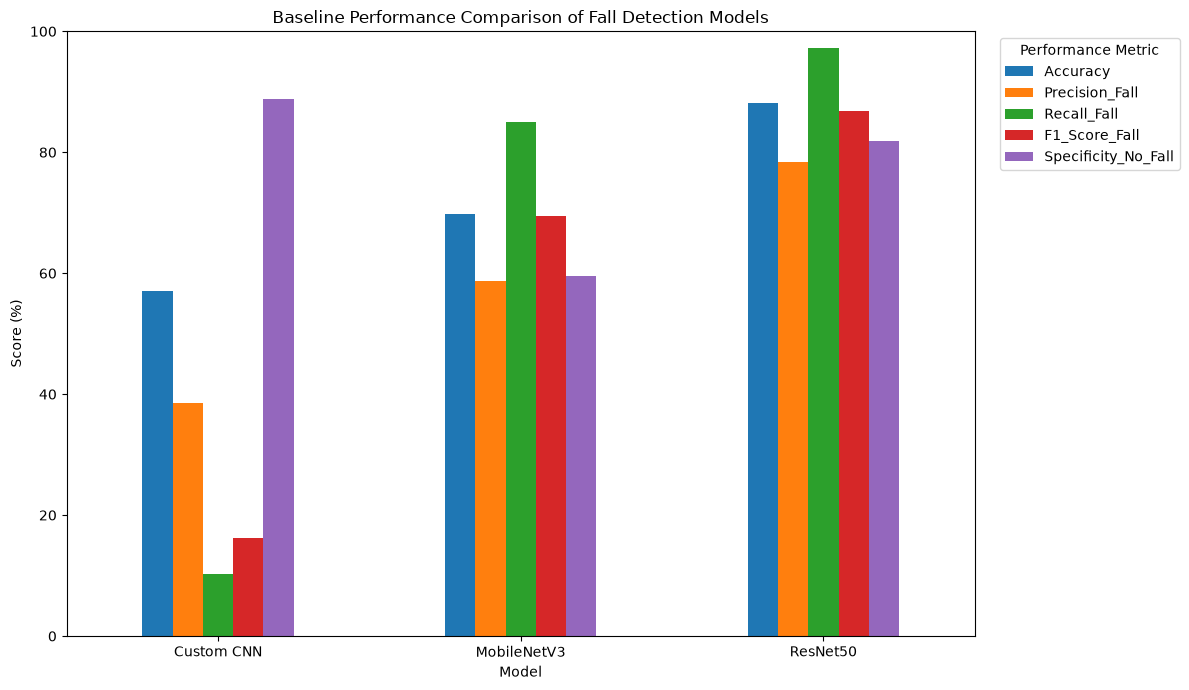

Comparison graph saved to:
C:\Users\GArvit\Desktop\Fall Detection\outputs\model_comparison\baseline_model_comparison.png


In [15]:
plot_columns = [
    "Accuracy",
    "Precision_Fall",
    "Recall_Fall",
    "F1_Score_Fall",
    "Specificity_No_Fall"
]

plot_dataframe = (
    comparison_dataframe
    .set_index("Model")[plot_columns]
    * 100
)

axis = plot_dataframe.plot(
    kind="bar",
    figsize=(12, 7)
)

axis.set_title(
    "Baseline Performance Comparison of Fall Detection Models"
)

axis.set_xlabel("Model")
axis.set_ylabel("Score (%)")
axis.set_ylim(0, 100)

axis.tick_params(
    axis="x",
    rotation=0
)

axis.legend(
    title="Performance Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

comparison_plot_path = (
    OUTPUT_DIRECTORY
    / "baseline_model_comparison.png"
)

plt.savefig(
    comparison_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Comparison graph saved to:"
)
print(
    comparison_plot_path.resolve()
)

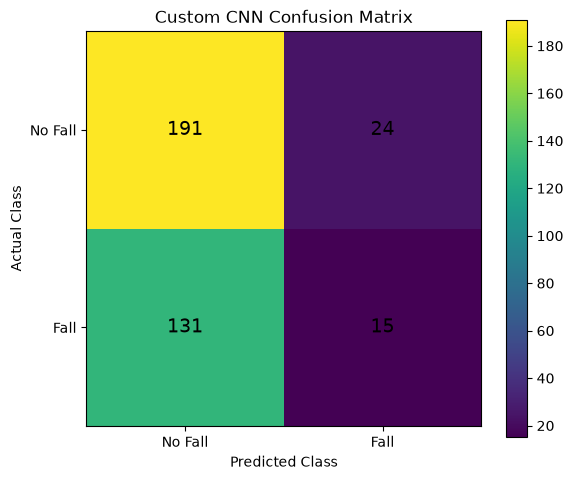

Custom CNN confusion matrix saved to:
C:\Users\GArvit\Desktop\Fall Detection\outputs\model_comparison\custom_cnn_baseline_confusion_matrix.png



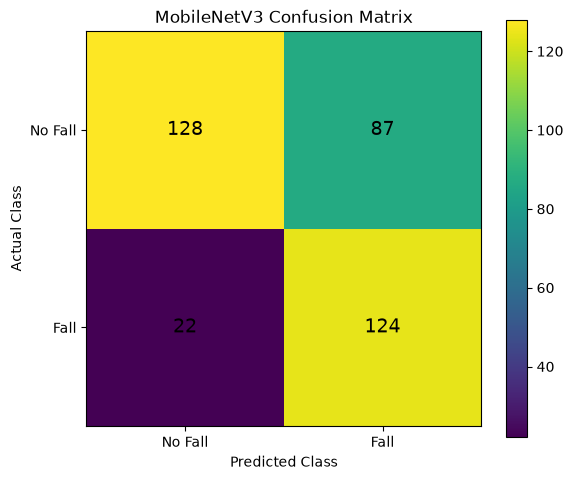

MobileNetV3 confusion matrix saved to:
C:\Users\GArvit\Desktop\Fall Detection\outputs\model_comparison\mobilenetv3_baseline_confusion_matrix.png



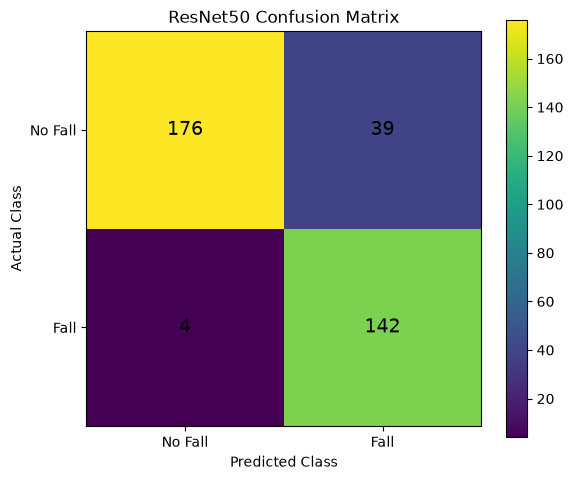

ResNet50 confusion matrix saved to:
C:\Users\GArvit\Desktop\Fall Detection\outputs\model_comparison\resnet50_baseline_confusion_matrix.png



In [16]:
for model_name, result in all_results.items():

    confusion = result["confusion_matrix"]

    figure, axis = plt.subplots(
        figsize=(6, 5)
    )

    image = axis.imshow(confusion)

    axis.set_title(
        f"{model_name} Confusion Matrix"
    )

    axis.set_xlabel("Predicted Class")
    axis.set_ylabel("Actual Class")

    axis.set_xticks([0, 1])
    axis.set_yticks([0, 1])

    axis.set_xticklabels([
        "No Fall",
        "Fall"
    ])

    axis.set_yticklabels([
        "No Fall",
        "Fall"
    ])

    for row_index in range(2):
        for column_index in range(2):

            axis.text(
                column_index,
                row_index,
                confusion[
                    row_index,
                    column_index
                ],
                ha="center",
                va="center",
                fontsize=14
            )

    figure.colorbar(
        image,
        ax=axis
    )

    plt.tight_layout()

    safe_model_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    confusion_path = (
        OUTPUT_DIRECTORY
        / f"{safe_model_name}_baseline_confusion_matrix.png"
    )

    plt.savefig(
        confusion_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"{model_name} confusion matrix saved to:"
    )
    print(confusion_path.resolve())
    print()

In [17]:
for model_name, result in all_results.items():

    safe_model_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    report_path = (
        OUTPUT_DIRECTORY
        / f"{safe_model_name}_baseline_classification_report.txt"
    )

    with open(
        report_path,
        "w",
        encoding="utf-8"
    ) as report_file:

        report_file.write(
            result["classification_report"]
        )

    print(
        f"{model_name} classification report saved to:"
    )
    print(report_path.resolve())
    print()

Custom CNN classification report saved to:
C:\Users\GArvit\Desktop\Fall Detection\outputs\model_comparison\custom_cnn_baseline_classification_report.txt

MobileNetV3 classification report saved to:
C:\Users\GArvit\Desktop\Fall Detection\outputs\model_comparison\mobilenetv3_baseline_classification_report.txt

ResNet50 classification report saved to:
C:\Users\GArvit\Desktop\Fall Detection\outputs\model_comparison\resnet50_baseline_classification_report.txt



In [18]:
metrics_to_maximise = {
    "Accuracy": "Accuracy",
    "Fall precision": "Precision_Fall",
    "Fall recall": "Recall_Fall",
    "Fall F1-score": "F1_Score_Fall",
    "No Fall specificity":
        "Specificity_No_Fall",
    "Balanced accuracy":
        "Balanced_Accuracy",
    "ROC-AUC": "ROC_AUC",
    "PR-AUC": "PR_AUC"
}

print("Best models by metric:\n")

for readable_name, column_name in (
    metrics_to_maximise.items()
):

    best_row_index = (
        comparison_dataframe[
            column_name
        ].idxmax()
    )

    best_model = (
        comparison_dataframe.loc[
            best_row_index,
            "Model"
        ]
    )

    best_score = (
        comparison_dataframe.loc[
            best_row_index,
            column_name
        ]
    )

    print(
        f"{readable_name}: "
        f"{best_model} "
        f"({best_score * 100:.2f}%)"
    )

Best models by metric:

Accuracy: ResNet50 (88.09%)
Fall precision: ResNet50 (78.45%)
Fall recall: ResNet50 (97.26%)
Fall F1-score: ResNet50 (86.85%)
No Fall specificity: Custom CNN (88.84%)
Balanced accuracy: ResNet50 (89.56%)
ROC-AUC: ResNet50 (97.70%)
PR-AUC: ResNet50 (96.59%)


PERFORMANCE METRICS FOR THE 3 MODELS AFTER TUNING

In [22]:
from pathlib import Path

PROJECT_ROOT = Path("..")

MODELS_DIRECTORY = PROJECT_ROOT / "models"

MODEL_PATHS = {
    "Tuned Custom CNN": (
        MODELS_DIRECTORY
        / "tuned_custom_cnn.keras"
    ),

    "Tuned MobileNetV3": (
        MODELS_DIRECTORY
        / "tuned_mobilenetv3.keras"
    ),

    "Tuned ResNet50": (
        MODELS_DIRECTORY
        / "tuned_resnet50.keras"
    )
}

In [23]:
for model_name, model_path in MODEL_PATHS.items():

    print(model_name)
    print(model_path.resolve())
    print("Exists:", model_path.exists())
    print()

Tuned Custom CNN
C:\Users\GArvit\Desktop\Fall Detection\models\tuned_custom_cnn.keras
Exists: True

Tuned MobileNetV3
C:\Users\GArvit\Desktop\Fall Detection\models\tuned_mobilenetv3.keras
Exists: True

Tuned ResNet50
C:\Users\GArvit\Desktop\Fall Detection\models\tuned_resnet50.keras
Exists: True



In [26]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
THRESHOLD = 0.50

CLASS_NAMES = [
    "no_fall",
    "fall"
]

In [27]:
baseline_metrics_path = (
    OUTPUT_DIRECTORY
    / "baseline_model_metrics.csv"
)

In [28]:
tuned_metrics_path = (
    OUTPUT_DIRECTORY
    / "tuned_model_metrics.csv"
)

comparison_dataframe.to_csv(
    tuned_metrics_path,
    index=False
)

print("Tuned metrics saved to:")
print(tuned_metrics_path.resolve())

Tuned metrics saved to:
C:\Users\GArvit\Desktop\Fall Detection\outputs\model_comparison\tuned_model_metrics.csv


In [30]:
f"{safe_model_name}_tuned_predictions.csv"

'resnet50_tuned_predictions.csv'

In [31]:
f"{safe_model_name}_tuned_confusion_matrix.png"

'resnet50_tuned_confusion_matrix.png'

In [51]:
baseline_path = OUTPUT_DIRECTORY / "baseline_model_metrics.csv"
tuned_path = OUTPUT_DIRECTORY / "tuned_model_metrics.csv"

baseline_results = pd.read_csv(baseline_path)
print("Baseline results:")
display(baseline_results)

if tuned_path.exists():
    tuned_results = pd.read_csv(tuned_path)
    print("\nTuned results:")
    display(tuned_results)
else:
    print("\nNo tuned metrics file found at:")
    print(tuned_path.resolve())
    print("Skipping tuned comparison.")
    tuned_results = baseline_results.copy()


Baseline results:


,Model,Threshold,Accuracy,Precision_Fall,Recall_Fall,Specificity_No_Fall,F1_Score_Fall,Negative_Predictive_Value,Balanced_Accuracy,ROC_AUC,PR_AUC,Binary_Crossentropy,True_Negative,False_Positive,False_Negative,True_Positive,Total_Prediction_Time_Seconds,Average_Time_Per_Image_Milliseconds,Images_Per_Second,Model_Size_MB
0,Custom CNN,0.5,0.570637,0.384615,0.102740,0.888372,0.162162,0.593168,0.495556,0.471488,0.381568,0.688317,191,24,131,15,2.458512,6.810283,146.836774,4.928472
1,MobileNetV3,0.5,0.698061,0.587678,0.849315,0.595349,0.694678,0.853333,0.722332,0.809079,0.716547,0.616494,128,87,22,124,2.517146,6.972705,143.416370,4.150707
2,ResNet50,0.5,0.880886,0.784530,0.972603,0.818605,0.868502,0.977778,0.895604,0.977031,0.965877,0.246924,176,39,4,142,12.259036,33.958548,29.447667,90.652433



No tuned metrics file found at:
C:\Users\GArvit\Desktop\Fall Detection\outputs\model_comparison\tuned_model_metrics.csv
Skipping tuned comparison.


In [52]:
baseline_selected = baseline_results[
    [
        "Model",
        "Accuracy",
        "Precision_Fall",
        "Recall_Fall",
        "F1_Score_Fall",
        "ROC_AUC",
        "PR_AUC",
        "False_Positive",
        "False_Negative"
    ]
].copy()

tuned_selected = tuned_results[
    [
        "Model",
        "Accuracy",
        "Precision_Fall",
        "Recall_Fall",
        "F1_Score_Fall",
        "ROC_AUC",
        "PR_AUC",
        "False_Positive",
        "False_Negative"
    ]
].copy()

In [34]:
baseline_selected["Model"] = (
    baseline_selected["Model"]
    .str.replace(
        "Custom CNN",
        "Custom CNN",
        regex=False
    )
    .str.replace(
        "MobileNetV3",
        "MobileNetV3",
        regex=False
    )
    .str.replace(
        "ResNet50",
        "ResNet50",
        regex=False
    )
)

tuned_selected["Model"] = (
    tuned_selected["Model"]
    .str.replace(
        "Tuned ",
        "",
        regex=False
    )
)

In [61]:
before_after_comparison = (
    baseline_selected.merge(
        tuned_selected,
        on="Model",
        suffixes=(
            "_Before",
            "_After"
        )
    )
)

display(before_after_comparison)

,Model,Accuracy_Before,Precision_Fall_Before,Recall_Fall_Before,F1_Score_Fall_Before,ROC_AUC_Before,PR_AUC_Before,False_Positive_Before,False_Negative_Before,Accuracy_After,Precision_Fall_After,Recall_Fall_After,F1_Score_Fall_After,ROC_AUC_After,PR_AUC_After,False_Positive_After,False_Negative_After
0,Custom CNN,0.570637,0.384615,0.102740,0.162162,0.471488,0.381568,24,131,0.570637,0.384615,0.102740,0.162162,0.471488,0.381568,24,131
1,MobileNetV3,0.698061,0.587678,0.849315,0.694678,0.809079,0.716547,87,22,0.698061,0.587678,0.849315,0.694678,0.809079,0.716547,87,22
2,ResNet50,0.880886,0.784530,0.972603,0.868502,0.977031,0.965877,39,4,0.880886,0.784530,0.972603,0.868502,0.977031,0.965877,39,4


In [36]:
for name, path in MODEL_PATHS.items():
    print(name)
    print(path)

Tuned Custom CNN
..\models\tuned_custom_cnn.keras
Tuned MobileNetV3
..\models\tuned_mobilenetv3.keras
Tuned ResNet50
..\models\tuned_resnet50.keras


In [37]:
for model_name, model_path in MODEL_PATHS.items():

    print("\nEvaluating:", model_name)
    print("Loading from:", model_path.resolve())

    model = tf.keras.models.load_model(
        model_path,
        custom_objects={
            "ResNet50Preprocessing": ResNet50Preprocessing
        }
    )

    print("Loaded model name:", model.name)
    print("Parameter count:", model.count_params())


Evaluating: Tuned Custom CNN
Loading from: C:\Users\GArvit\Desktop\Fall Detection\models\tuned_custom_cnn.keras


NameError: name 'ResNet50Preprocessing' is not defined

In [38]:
@tf.keras.utils.register_keras_serializable(
    package="FallDetection"
)
class ResNet50Preprocessing(tf.keras.layers.Layer):

    def call(self, inputs):
        return tf.keras.applications.resnet50.preprocess_input(
            inputs
        )

    def get_config(self):
        return super().get_config()

In [39]:
loaded_models = {}

for model_name, model_path in MODEL_PATHS.items():

    print("\n" + "=" * 70)
    print("Evaluating:", model_name)
    print("Loading from:", model_path.resolve())
    print("=" * 70)

    model = tf.keras.models.load_model(
        model_path,
        custom_objects={
            "ResNet50Preprocessing": ResNet50Preprocessing
        }
    )

    loaded_models[model_name] = model

    print("Loaded model name:", model.name)
    print("Parameter count:", model.count_params())


Evaluating: Tuned Custom CNN
Loading from: C:\Users\GArvit\Desktop\Fall Detection\models\tuned_custom_cnn.keras
Loaded model name: tuned_custom_cnn
Parameter count: 422881

Evaluating: Tuned MobileNetV3
Loading from: C:\Users\GArvit\Desktop\Fall Detection\models\tuned_mobilenetv3.keras
Loaded model name: tuned_mobilenetv3
Parameter count: 1013105

Evaluating: Tuned ResNet50
Loading from: C:\Users\GArvit\Desktop\Fall Detection\models\tuned_resnet50.keras

Loaded model name: tuned_resnet50
Parameter count: 24112513


In [42]:
loaded_models = {}

for model_name, model_path in MODEL_PATHS.items():

    print("\n" + "=" * 70)
    print("Evaluating:", model_name)
    print("Loading from:", model_path.resolve())
    print("=" * 70)

    model = tf.keras.models.load_model(
        model_path,
        custom_objects={
            "ResNet50Preprocessing": ResNet50Preprocessing
        }
    )

    loaded_models[model_name] = model

    print("Loaded model name:", model.name)
    print("Parameter count:", model.count_params())


Evaluating: Tuned Custom CNN
Loading from: C:\Users\GArvit\Desktop\Fall Detection\models\tuned_custom_cnn.keras
Loaded model name: tuned_custom_cnn
Parameter count: 422881

Evaluating: Tuned MobileNetV3
Loading from: C:\Users\GArvit\Desktop\Fall Detection\models\tuned_mobilenetv3.keras
Loaded model name: tuned_mobilenetv3
Parameter count: 1013105

Evaluating: Tuned ResNet50
Loading from: C:\Users\GArvit\Desktop\Fall Detection\models\tuned_resnet50.keras
Loaded model name: tuned_resnet50
Parameter count: 24112513


In [43]:
TUNED_METRICS_PATH = (
    OUTPUT_DIRECTORY /
    "tuned_model_metrics.csv"
)

if TUNED_METRICS_PATH.exists():
    TUNED_METRICS_PATH.unlink()

print("Old tuned metrics removed.")

Old tuned metrics removed.


In [44]:
all_tuned_results = []

for model_name, model_path in MODEL_PATHS.items():

    print("\nEvaluating:", model_name)

    model = tf.keras.models.load_model(
        model_path,
        custom_objects={
            "ResNet50Preprocessing": ResNet50Preprocessing
        }
    )

    predicted_probabilities = model.predict(
        validation_dataset,
        verbose=1
    ).reshape(-1)

    predicted_labels = (
        predicted_probabilities >= 0.5
    ).astype(int)

    # Calculate metrics here using these new predictions.


Evaluating: Tuned Custom CNN
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 216ms/step

Evaluating: Tuned MobileNetV3
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 170ms/step

Evaluating: Tuned ResNet50
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step 


In [54]:
tuned_results = []

for model_name, model_path in MODEL_PATHS.items():

    print("Evaluating:", model_name)

    model = tf.keras.models.load_model(
        model_path,
        custom_objects={
            "ResNet50Preprocessing": ResNet50Preprocessing
        }
    )

    predicted_probabilities = model.predict(
        validation_dataset,
        verbose=1
    ).reshape(-1)

    predicted_labels = (
        predicted_probabilities >= THRESHOLD
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        validation_labels,
        predicted_labels,
        labels=[0, 1]
    ).ravel()

    accuracy = accuracy_score(
        validation_labels,
        predicted_labels
    )

    precision = precision_score(
        validation_labels,
        predicted_labels,
        zero_division=0
    )

    recall = recall_score(
        validation_labels,
        predicted_labels,
        zero_division=0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    f1 = f1_score(
        validation_labels,
        predicted_labels,
        zero_division=0
    )

    negative_predictive_value = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else 0
    )

    balanced_accuracy = (
        recall + specificity
    ) / 2

    roc_auc = roc_auc_score(
        validation_labels,
        predicted_probabilities
    )

    pr_auc = average_precision_score(
        validation_labels,
        predicted_probabilities
    )

    binary_crossentropy = log_loss(
        validation_labels,
        predicted_probabilities,
        labels=[0, 1]
    )

    clean_model_name = model_name.replace(
        "Tuned ",
        ""
    )

    tuned_results.append({
        "Model": clean_model_name,
        "Threshold": THRESHOLD,
        "Accuracy": accuracy,
        "Precision_Fall": precision,
        "Recall_Fall": recall,
        "Specificity_No_Fall": specificity,
        "F1_Score_Fall": f1,
        "Negative_Predictive_Value": negative_predictive_value,
        "Balanced_Accuracy": balanced_accuracy,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "Binary_Crossentropy": binary_crossentropy,
        "True_Negative": tn,
        "False_Positive": fp,
        "False_Negative": fn,
        "True_Positive": tp
    })

tuned_results_dataframe = pd.DataFrame(
    tuned_results
)

display(tuned_results_dataframe)


Evaluating: Tuned Custom CNN
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 193ms/step
Evaluating: Tuned MobileNetV3
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step
Evaluating: Tuned ResNet50
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 873ms/step


,Model,Threshold,Accuracy,Precision_Fall,Recall_Fall,Specificity_No_Fall,F1_Score_Fall,Negative_Predictive_Value,Balanced_Accuracy,ROC_AUC,PR_AUC,Binary_Crossentropy,True_Negative,False_Positive,False_Negative,True_Positive
0,Custom CNN,0.5,0.584488,0.487805,0.547945,0.609302,0.516129,0.664975,0.578624,0.591303,0.474115,0.678801,131,84,66,80
1,MobileNetV3,0.5,0.781163,0.673575,0.890411,0.706977,0.766962,0.904762,0.798694,0.898120,0.840137,0.446966,152,63,16,130
2,ResNet50,0.5,0.927978,0.976190,0.842466,0.986047,0.904412,0.902128,0.914256,0.990124,0.985137,0.193483,212,3,23,123


In [55]:
tuned_metrics_path = (
    OUTPUT_DIRECTORY /
    "tuned_model_metrics.csv"
)

tuned_results_dataframe.to_csv(
    tuned_metrics_path,
    index=False
)

print("Tuned metrics saved to:")
print(tuned_metrics_path.resolve())

Tuned metrics saved to:
C:\Users\GArvit\Desktop\Fall Detection\outputs\model_comparison\tuned_model_metrics.csv


In [56]:
baseline_results = pd.read_csv(
    OUTPUT_DIRECTORY /
    "baseline_model_metrics.csv"
)

tuned_results = pd.read_csv(
    OUTPUT_DIRECTORY /
    "tuned_model_metrics.csv"
)

comparison = baseline_results.merge(
    tuned_results,
    on="Model",
    suffixes=("_Before", "_After")
)

metrics_to_compare = [
    "Accuracy",
    "Precision_Fall",
    "Recall_Fall",
    "Specificity_No_Fall",
    "F1_Score_Fall",
    "Balanced_Accuracy",
    "ROC_AUC",
    "PR_AUC"
]

for metric in metrics_to_compare:
    comparison[f"{metric}_Change"] = (
        comparison[f"{metric}_After"]
        - comparison[f"{metric}_Before"]
    )

comparison["False_Positive_Change"] = (
    comparison["False_Positive_After"]
    - comparison["False_Positive_Before"]
)

comparison["False_Negative_Change"] = (
    comparison["False_Negative_After"]
    - comparison["False_Negative_Before"]
)

display(comparison)

,Model,Threshold_Before,Accuracy_Before,Precision_Fall_Before,Recall_Fall_Before,Specificity_No_Fall_Before,F1_Score_Fall_Before,Negative_Predictive_Value_Before,Balanced_Accuracy_Before,ROC_AUC_Before,...,Accuracy_Change,Precision_Fall_Change,Recall_Fall_Change,Specificity_No_Fall_Change,F1_Score_Fall_Change,Balanced_Accuracy_Change,ROC_AUC_Change,PR_AUC_Change,False_Positive_Change,False_Negative_Change
0,Custom CNN,0.5,0.570637,0.384615,0.102740,0.888372,0.162162,0.593168,0.495556,0.471488,...,0.013850,0.103189,0.445205,-0.279070,0.353967,0.083068,0.119815,0.092547,60,-65
1,MobileNetV3,0.5,0.698061,0.587678,0.849315,0.595349,0.694678,0.853333,0.722332,0.809079,...,0.083102,0.085897,0.041096,0.111628,0.072284,0.076362,0.089041,0.123590,-24,-6
2,ResNet50,0.5,0.880886,0.784530,0.972603,0.818605,0.868502,0.977778,0.895604,0.977031,...,0.047091,0.191660,-0.130137,0.167442,0.035910,0.018652,0.013093,0.019260,-36,19


In [57]:
baseline_results = pd.read_csv(
    OUTPUT_DIRECTORY / "baseline_model_metrics.csv"
)

tuned_results = pd.read_csv(
    OUTPUT_DIRECTORY / "tuned_model_metrics.csv"
)

In [58]:
performance_metrics = [
    "Model",
    "Accuracy",
    "Precision_Fall",
    "Recall_Fall",
    "Specificity_No_Fall",
    "F1_Score_Fall",
    "Balanced_Accuracy",
    "ROC_AUC",
    "PR_AUC"
]

baseline_performance = baseline_results[
    performance_metrics
].copy()

tuned_performance = tuned_results[
    performance_metrics
].copy()

performance_comparison = baseline_performance.merge(
    tuned_performance,
    on="Model",
    suffixes=("_Baseline", "_Tuned")
)

metrics = [
    "Accuracy",
    "Precision_Fall",
    "Recall_Fall",
    "Specificity_No_Fall",
    "F1_Score_Fall",
    "Balanced_Accuracy",
    "ROC_AUC",
    "PR_AUC"
]

for metric in metrics:
    performance_comparison[f"{metric}_Change"] = (
        performance_comparison[f"{metric}_Tuned"]
        - performance_comparison[f"{metric}_Baseline"]
    )

display(performance_comparison.round(4))

,Model,Accuracy_Baseline,Precision_Fall_Baseline,Recall_Fall_Baseline,Specificity_No_Fall_Baseline,F1_Score_Fall_Baseline,Balanced_Accuracy_Baseline,ROC_AUC_Baseline,PR_AUC_Baseline,Accuracy_Tuned,...,ROC_AUC_Tuned,PR_AUC_Tuned,Accuracy_Change,Precision_Fall_Change,Recall_Fall_Change,Specificity_No_Fall_Change,F1_Score_Fall_Change,Balanced_Accuracy_Change,ROC_AUC_Change,PR_AUC_Change
0,Custom CNN,0.5706,0.3846,0.1027,0.8884,0.1622,0.4956,0.4715,0.3816,0.5845,...,0.5913,0.4741,0.0139,0.1032,0.4452,-0.2791,0.3540,0.0831,0.1198,0.0925
1,MobileNetV3,0.6981,0.5877,0.8493,0.5953,0.6947,0.7223,0.8091,0.7165,0.7812,...,0.8981,0.8401,0.0831,0.0859,0.0411,0.1116,0.0723,0.0764,0.0890,0.1236
2,ResNet50,0.8809,0.7845,0.9726,0.8186,0.8685,0.8956,0.9770,0.9659,0.9280,...,0.9901,0.9851,0.0471,0.1917,-0.1301,0.1674,0.0359,0.0187,0.0131,0.0193


In [59]:
error_metrics = [
    "Model",
    "True_Negative",
    "False_Positive",
    "False_Negative",
    "True_Positive"
]

baseline_errors = baseline_results[
    error_metrics
].copy()

tuned_errors = tuned_results[
    error_metrics
].copy()

error_comparison = baseline_errors.merge(
    tuned_errors,
    on="Model",
    suffixes=("_Baseline", "_Tuned")
)

error_columns = [
    "True_Negative",
    "False_Positive",
    "False_Negative",
    "True_Positive"
]

for column in error_columns:
    error_comparison[f"{column}_Change"] = (
        error_comparison[f"{column}_Tuned"]
        - error_comparison[f"{column}_Baseline"]
    )

display(error_comparison)

,Model,True_Negative_Baseline,False_Positive_Baseline,False_Negative_Baseline,True_Positive_Baseline,True_Negative_Tuned,False_Positive_Tuned,False_Negative_Tuned,True_Positive_Tuned,True_Negative_Change,False_Positive_Change,False_Negative_Change,True_Positive_Change
0,Custom CNN,191,24,131,15,131,84,66,80,-60,60,-65,65
1,MobileNetV3,128,87,22,124,152,63,16,130,24,-24,-6,6
2,ResNet50,176,39,4,142,212,3,23,123,36,-36,19,-19


In [60]:
performance_comparison_path = (
    OUTPUT_DIRECTORY /
    "performance_metrics_before_after.csv"
)

error_comparison_path = (
    OUTPUT_DIRECTORY /
    "confusion_matrix_before_after.csv"
)

performance_comparison.to_csv(
    performance_comparison_path,
    index=False
)

error_comparison.to_csv(
    error_comparison_path,
    index=False
)

print("Performance comparison saved to:")
print(performance_comparison_path.resolve())

print("\nError comparison saved to:")
print(error_comparison_path.resolve())

Performance comparison saved to:
C:\Users\GArvit\Desktop\Fall Detection\outputs\model_comparison\performance_metrics_before_after.csv

Error comparison saved to:
C:\Users\GArvit\Desktop\Fall Detection\outputs\model_comparison\confusion_matrix_before_after.csv


In [3]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("..")

OUTPUT_DIRECTORY = (
    PROJECT_ROOT /
    "outputs" /
    "model_comparison"
)

print(OUTPUT_DIRECTORY.resolve())
baseline_results = pd.read_csv(
    OUTPUT_DIRECTORY / "baseline_model_metrics.csv"
)

tuned_results = pd.read_csv(
    OUTPUT_DIRECTORY / "tuned_model_metrics.csv"
)

performance_columns = [
    "Model",
    "Accuracy",
    "Precision_Fall",
    "Recall_Fall",
    "Specificity_No_Fall",
    "F1_Score_Fall",
    "Balanced_Accuracy",
    "ROC_AUC",
    "PR_AUC"
]

print("BASELINE PERFORMANCE METRICS")
display(
    baseline_results[performance_columns].round(4)
)

print("\nTUNED PERFORMANCE METRICS")
display(
    tuned_results[performance_columns].round(4)
)

C:\Users\GArvit\Desktop\Fall Detection\outputs\model_comparison
BASELINE PERFORMANCE METRICS


,Model,Accuracy,Precision_Fall,Recall_Fall,Specificity_No_Fall,F1_Score_Fall,Balanced_Accuracy,ROC_AUC,PR_AUC
0,Custom CNN,0.5706,0.3846,0.1027,0.8884,0.1622,0.4956,0.4715,0.3816
1,MobileNetV3,0.6981,0.5877,0.8493,0.5953,0.6947,0.7223,0.8091,0.7165
2,ResNet50,0.8809,0.7845,0.9726,0.8186,0.8685,0.8956,0.9770,0.9659



TUNED PERFORMANCE METRICS


,Model,Accuracy,Precision_Fall,Recall_Fall,Specificity_No_Fall,F1_Score_Fall,Balanced_Accuracy,ROC_AUC,PR_AUC
0,Custom CNN,0.5845,0.4878,0.5479,0.6093,0.5161,0.5786,0.5913,0.4741
1,MobileNetV3,0.7812,0.6736,0.8904,0.7070,0.7670,0.7987,0.8981,0.8401
2,ResNet50,0.9280,0.9762,0.8425,0.9860,0.9044,0.9143,0.9901,0.9851


In [4]:
comparison_table = baseline_results[
    [
        "Model",
        "Accuracy",
        "Precision_Fall",
        "Recall_Fall",
        "F1_Score_Fall",
        "ROC_AUC",
        "PR_AUC"
    ]
].merge(
    tuned_results[
        [
            "Model",
            "Accuracy",
            "Precision_Fall",
            "Recall_Fall",
            "F1_Score_Fall",
            "ROC_AUC",
            "PR_AUC"
        ]
    ],
    on="Model",
    suffixes=("_Baseline", "_Tuned")
)

display(comparison_table.round(4))

,Model,Accuracy_Baseline,Precision_Fall_Baseline,Recall_Fall_Baseline,F1_Score_Fall_Baseline,ROC_AUC_Baseline,PR_AUC_Baseline,Accuracy_Tuned,Precision_Fall_Tuned,Recall_Fall_Tuned,F1_Score_Fall_Tuned,ROC_AUC_Tuned,PR_AUC_Tuned
0,Custom CNN,0.5706,0.3846,0.1027,0.1622,0.4715,0.3816,0.5845,0.4878,0.5479,0.5161,0.5913,0.4741
1,MobileNetV3,0.6981,0.5877,0.8493,0.6947,0.8091,0.7165,0.7812,0.6736,0.8904,0.7670,0.8981,0.8401
2,ResNet50,0.8809,0.7845,0.9726,0.8685,0.9770,0.9659,0.9280,0.9762,0.8425,0.9044,0.9901,0.9851
